# A/B Test Calculator: Design & Analysis

This calculator helps you at two stages of an A/B test:

- **Design:** before the test — figure out how many users you need and how long to run.
- **Analysis:** after the test — determine whether to ship, based on both superiority and non-inferiority.

Use the toggle at the top to switch between modes.

**Assumptions:** binary metric (conversion rate), independent observations, large-sample approximation, fixed-horizon test. This tool covers the primary metric only; guardrail metrics should be checked separately.

---

## Design Mode

Plan your experiment before launch. The calculator gives you the required sample size for both superiority and non-inferiority tests, so you can cover both with a single run.

| Field | What it means | Example |
|---|---|---|
| **Baseline CR (%)** | Current conversion rate in the control experience | 11.30 |
| **MDE (p.p.)** | Minimum detectable effect — the smallest improvement you want to be able to detect | 0.10 |
| **NI margin (p.p.)** | Maximum acceptable drop — the worst-case decline you are willing to live with. Set this as a team before the test. | 0.10 |
| **Alpha** | False positive rate. 0.05 is standard for most tests. | 0.05 |
| **Power** | Probability of detecting a real effect. 0.80 is standard. | 0.80 |
| **Ratio (treatment/control)** | How many treatment users per one control user. 1.0 = equal split. 2.0 = treatment group is twice as large. | 1.0 |
| **Daily traffic** | Total users entering the experiment per day (both groups combined). Used to estimate duration. | 10,000 |

**Output:** sample size per group, total users, and estimated days — separately for superiority and non-inferiority. The recommendation at the bottom tells you which number to use (always the larger one, so both tests have enough data).

---

## Analysis Mode

After the test is finished, enter the actual results. Groups can have different sizes — this is handled correctly.

| Field | What it means | Example |
|---|---|---|
| **Conversions control** | Number of conversions in the control group | 56,500 |
| **N control** | Total users in the control group | 500,000 |
| **Conversions treatment** | Number of conversions in the treatment group | 56,250 |
| **N treatment** | Total users in the treatment group | 500,000 |
| **NI margin (p.p.)** | Same margin you agreed on before the test | 0.10 |
| **Alpha** | Same alpha you used in the design. Must match. | 0.05 |

**Output:** two charts, a decision, and a text report.

**Top chart (Superiority):** is the treatment better or worse? The confidence interval is shown relative to zero.

**Bottom chart (Non-Inferiority):** is the drop acceptable? The same confidence interval is shown relative to the margin line. The NI decision is based on whether the lower bound of the CI stays above -margin.

**Decision** is one of five outcomes:

| # | Superiority result | NI shown? | Decision | What it means |
|---|---|---|---|---|
| 1 | Treatment better | Yes | **Ship** | Treatment is better. |
| 2 | Not significant | Yes | **Safe to ship** | No difference detected, but the CI confirms the drop is within the acceptable margin. |
| 3 | Not significant | No | **Don't ship** | Cannot guarantee the drop is acceptable. CI crosses the margin boundary. |
| 4 | Treatment worse | Yes | **Safe to ship*** | Significantly worse, but within the margin. Product team decides. |
| 5 | Treatment worse | No | **Don't ship** | Worse beyond the acceptable limit. |

The calculator highlights which row applies to your test.

**SRM check:** if the group sizes look imbalanced (more than expected), the calculator prints a warning. This may indicate an allocation bug — check before trusting the results.

---

## When to use which mode

**Design** — when planning a new test. Run it once, agree on the margin with your PM and EM, then launch.

**Analysis** — when the test is done. Works for any A/B test, not just non-inferiority. If the result is "no significant difference" and you want to know whether shipping is safe — this is exactly what you need.

---

## Two things to remember

**Margin is a product decision.** It is not a statistical parameter. It means: "we are OK with losing at most this much." Always set it before the test starts. Do not change it after you see the results.

**Alpha must be the same in Design and Analysis.** If you designed the test with alpha = 0.05, analyze it with the same value. Changing alpha after seeing results invalidates the test.

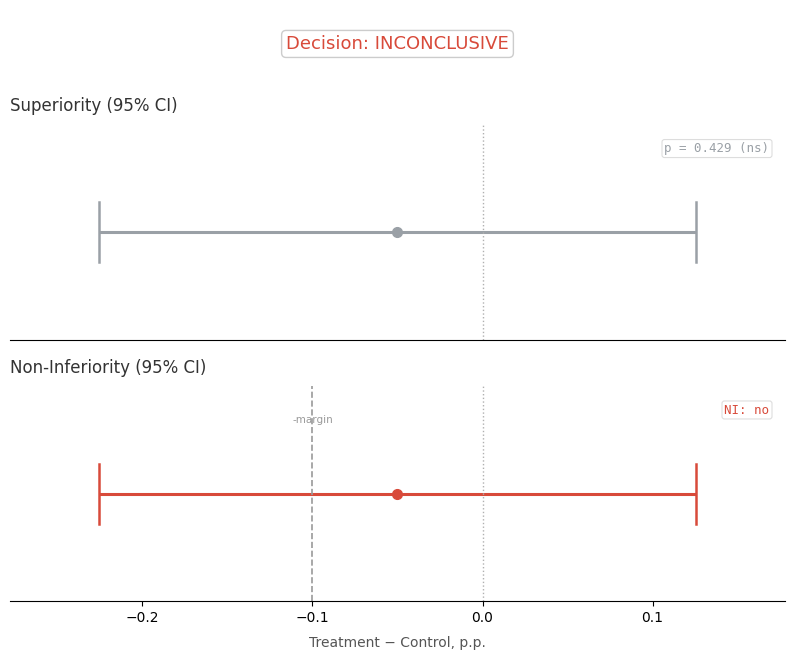

  Control:   56,500 / 500,000 = 11.3000%
  Treatment: 56,250 / 500,000 = 11.2500%
  Diff (T-C): -0.0500 p.p.
  95% CI:    [-0.2253, 0.1253] p.p.  (Newcombe)
  Superiority p-value: 0.4293 (alpha=0.05, two-sided)
  NI margin: 0.1000 p.p.
  NI decision is based on the lower bound of the 95% CI
  Worst-case drop from CI lower bound: 0.2253 p.p.
------------------------------------------------------------------------

  #   Superiority         NI?     Decision        Comment
  ────────────────────────────────────────────────────────────────────────
    1   Treatment better    Yes     Ship            Treatment is better.
    2   Not significant     Yes     Safe to ship    CI above -margin.
 >>>3   Not significant     No      Don't ship      CI crosses -margin.
    4   Treatment worse     Yes     Safe to ship*   Within margin. Product decides.
    5   Treatment worse     No      Don't ship      Beyond margin.

  >>> INCONCLUSIVE: We cannot rule out a drop larger than the margin. The CI crosse

In [ ]:
#@title A/B Test Calculator: Design & Analysis { run: "auto", display-mode: "form" }

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output


# ══════════════════════════════════════════════════════════════
# CORE STATISTICAL FUNCTIONS
# ══════════════════════════════════════════════════════════════

def _wilson_interval(successes, n, z):
    """Wilson score interval for a single proportion."""
    p_hat = successes / n
    denom = 1 + z ** 2 / n
    center = (p_hat + z ** 2 / (2 * n)) / denom
    hw = (z / denom) * np.sqrt(p_hat * (1 - p_hat) / n + z ** 2 / (4 * n ** 2))
    return center - hw, center + hw


def _newcombe_ci(conv_c, n_c, conv_t, n_t, alpha):
    """
    Newcombe (1998) Method 10:
    CI for difference (treatment - control) = [l2 - u1, u2 - l1]
    where l/u are Wilson intervals for each group.
    """
    z = stats.norm.ppf(1 - alpha / 2)
    l1, u1 = _wilson_interval(conv_c, n_c, z)  # control
    l2, u2 = _wilson_interval(conv_t, n_t, z)  # treatment

    cr_control = conv_c / n_c
    cr_treatment = conv_t / n_t
    diff = cr_treatment - cr_control

    ci_lower = l2 - u1
    ci_upper = u2 - l1

    return cr_control, cr_treatment, diff, ci_lower, ci_upper


def _pooled_p_value(conv_c, n_c, conv_t, n_t):
    """Two-sided superiority p-value (pooled z-test under H0: cr_c = cr_t)."""
    diff = conv_t / n_t - conv_c / n_c
    p_pooled = (conv_c + conv_t) / (n_c + n_t)
    se = np.sqrt(p_pooled * (1 - p_pooled) * (1 / n_c + 1 / n_t))
    if se == 0:
        return 1.0
    return 2 * (1 - stats.norm.cdf(abs(diff / se)))


def _classify(ci_lower, ci_upper, margin, sig, diff):
    """Classify result: WIN / SAFE TO SHIP / SAFE TO SHIP* / INCONCLUSIVE / LOSS."""
    if ci_lower > 0:
        return "WIN", True, "Treatment is significantly better than control."
    elif ci_lower > -margin and not (sig and diff < 0):
        return "SAFE TO SHIP", True, (
            "No significant difference. "
            "The CI does not indicate a drop beyond the acceptable margin."
        )
    elif ci_lower > -margin and sig and diff < 0:
        return "SAFE TO SHIP*", True, (
            "Treatment is significantly worse, but within the acceptable margin. "
            "Product team decides."
        )
    elif ci_upper < -margin:
        return "LOSS", False, "Treatment is worse than control beyond the acceptable margin."
    else:
        return "INCONCLUSIVE", False, (
            "We cannot rule out a drop larger than the margin. "
            "The CI crosses the non-inferiority boundary."
        )


def _check_srm(n_c, n_t, expected_ratio=None):
    """
    Check for sample ratio mismatch.
    Returns warning string or None.
    """
    if expected_ratio is None:
        expected_ratio = 1.0
    observed_ratio = n_t / n_c if n_c > 0 else float("inf")
    deviation = abs(observed_ratio - expected_ratio) / expected_ratio
    if deviation > 0.01:
        # Chi-squared SRM test
        total = n_c + n_t
        expected_c = total / (1 + expected_ratio)
        expected_t = total * expected_ratio / (1 + expected_ratio)
        chi2 = (n_c - expected_c) ** 2 / expected_c + (n_t - expected_t) ** 2 / expected_t
        srm_p = 1 - stats.chi2.cdf(chi2, df=1)
        if srm_p < 0.001:
            return (
                f"SRM WARNING: group ratio = {observed_ratio:.4f} "
                f"(expected {expected_ratio:.2f}), SRM p-value = {srm_p:.6f}. "
                f"Check allocation logic before trusting results."
            )
    return None


# ══════════════════════════════════════════════════════════════
# DESIGN MODE
# ══════════════════════════════════════════════════════════════

def run_design(baseline_cr, mde, margin, alpha, power, ratio, daily_traffic):
    clear_output(wait=True)
    display(ui)

    errors = []
    if not (0 < baseline_cr < 1):
        errors.append(f"Baseline CR must be between 0% and 100%. Got {baseline_cr:.4%}.")
    if mde <= 0:
        errors.append(f"MDE must be positive. Got {mde}.")
    if margin <= 0:
        errors.append(f"Margin must be positive. Got {margin}.")
    if not (0 < alpha < 1):
        errors.append(f"Alpha must be between 0 and 1. Got {alpha}.")
    if not (0 < power < 1):
        errors.append(f"Power must be between 0 and 1. Got {power}.")
    if ratio <= 0:
        errors.append(f"Ratio must be positive. Got {ratio}.")
    if 0 < baseline_cr < 1 and mde > 0 and baseline_cr + mde >= 1:
        errors.append(f"Baseline + MDE = {baseline_cr + mde:.4f} >= 1.")
    if 0 < baseline_cr < 1 and margin > 0 and baseline_cr - margin <= 0:
        errors.append(f"Baseline - Margin = {baseline_cr - margin:.4f} <= 0.")
    if errors:
        for e in errors:
            print(f"  ERROR: {e}")
        return

    z_a = stats.norm.ppf(1 - alpha / 2)
    z_b = stats.norm.ppf(power)
    cr_control = baseline_cr
    cr_treatment = baseline_cr + mde

    # Sample size based on normal approximation for two proportions
    # with unequal allocation (Fleiss formula)

    # Superiority
    p_bar = (cr_control + cr_treatment) / 2
    se_h0_sup = np.sqrt(p_bar * (1 - p_bar) * (1 + 1 / ratio))
    se_h1_sup = np.sqrt(cr_control * (1 - cr_control) + cr_treatment * (1 - cr_treatment) / ratio)
    n_c_sup = int(np.ceil(((z_a * se_h0_sup + z_b * se_h1_sup) / mde) ** 2))
    n_t_sup = int(np.ceil(n_c_sup * ratio))

    # Non-inferiority
    cr_t_h0 = cr_control - margin
    cr_t_h1 = cr_control
    se_h0_ni = np.sqrt(cr_control * (1 - cr_control) + cr_t_h0 * (1 - cr_t_h0) / ratio)
    se_h1_ni = np.sqrt(cr_control * (1 - cr_control) + cr_t_h1 * (1 - cr_t_h1) / ratio)
    n_c_ni = int(np.ceil(((z_a * se_h0_ni + z_b * se_h1_ni) / margin) ** 2))
    n_t_ni = int(np.ceil(n_c_ni * ratio))

    n_total_sup = n_c_sup + n_t_sup
    n_total_ni = n_c_ni + n_t_ni
    n_max = max(n_total_sup, n_total_ni)
    ci_pct = f"{(1 - alpha) * 100:.0f}%"

    days_sup = int(np.ceil(n_total_sup / daily_traffic)) if daily_traffic > 0 else None
    days_ni = int(np.ceil(n_total_ni / daily_traffic)) if daily_traffic > 0 else None

    print("=" * 64)
    print("              EXPERIMENT DESIGN")
    print("=" * 64)
    print(f"  Baseline CR:      {baseline_cr:.4%}")
    print(f"  MDE:              {mde * 100:.4f} p.p.")
    print(f"  NI margin:        {margin * 100:.4f} p.p.")
    print(f"  Alpha:            {alpha}  ({ci_pct} two-sided CI; NI uses lower bound)")
    print(f"  Power:            {power:.0%}")
    print(f"  Group ratio:      {ratio} (treatment / control)")
    if daily_traffic > 0:
        print(f"  Daily traffic:    {daily_traffic:,}")
    print("-" * 64)
    print()
    print(f"  {'':30s} {'Superiority':>15s}   {'Non-Inferiority':>15s}")
    print(f"  {'─' * 30} {'─' * 15}   {'─' * 15}")
    print(f"  {'N control':30s} {n_c_sup:>15,}   {n_c_ni:>15,}")
    print(f"  {'N treatment':30s} {n_t_sup:>15,}   {n_t_ni:>15,}")
    print(f"  {'N total':30s} {n_total_sup:>15,}   {n_total_ni:>15,}")
    if daily_traffic > 0:
        print(f"  {'Estimated duration':30s} {days_sup:>12,} d   {days_ni:>12,} d")
    print()
    print("  Recommendation:")
    if daily_traffic > 0:
        days_max = int(np.ceil(n_max / daily_traffic))
        print(f"  Run for {days_max:,} days ({n_max:,} users) to cover both tests.")
    else:
        print(f"  Collect {n_max:,} users total to cover both tests.")
    print("=" * 64)


# ══════════════════════════════════════════════════════════════
# ANALYSIS MODE
# ══════════════════════════════════════════════════════════════

def run_analysis(conv_c, conv_t, n_c, n_t, margin, alpha):
    clear_output(wait=True)
    display(ui)

    errors = []
    if n_c <= 0:
        errors.append(f"N control must be positive. Got {n_c}.")
    if n_t <= 0:
        errors.append(f"N treatment must be positive. Got {n_t}.")
    if conv_c < 0:
        errors.append(f"Conversions control must be >= 0. Got {conv_c}.")
    if conv_t < 0:
        errors.append(f"Conversions treatment must be >= 0. Got {conv_t}.")
    if n_c > 0 and conv_c > n_c:
        errors.append(f"Conversions control ({conv_c}) > N control ({n_c}).")
    if n_t > 0 and conv_t > n_t:
        errors.append(f"Conversions treatment ({conv_t}) > N treatment ({n_t}).")
    if margin <= 0:
        errors.append(f"Margin must be positive. Got {margin}.")
    if not (0 < alpha < 1):
        errors.append(f"Alpha must be between 0 and 1. Got {alpha}.")
    if errors:
        for e in errors:
            print(f"  ERROR: {e}")
        return

    # Compute
    cr_c, cr_t, diff, ci_lower, ci_upper = _newcombe_ci(conv_c, n_c, conv_t, n_t, alpha)
    sup_p_value = _pooled_p_value(conv_c, n_c, conv_t, n_t)
    sig = sup_p_value < alpha
    decision, ni_passed, interpretation = _classify(ci_lower, ci_upper, margin, sig, diff)

    # Worst-case drop from CI lower bound (not a guaranteed bound)
    worst_case_drop = max(0.0, -ci_lower)

    ci_pct = f"{(1 - alpha) * 100:.0f}%"

    # Row mapping
    if decision == "WIN":
        row_num = "1"
    elif decision == "SAFE TO SHIP":
        row_num = "2"
    elif decision == "SAFE TO SHIP*":
        row_num = "4"
    elif decision == "LOSS":
        row_num = "5"
    else:
        row_num = "3"

    # SRM check
    srm_warning = _check_srm(n_c, n_t)

    # ── Colors ──
    GREEN = "#2e8b57"
    RED = "#d84a3a"
    NEUTRAL = "#9aa0a6"

    # ── Layout ──
    fig = plt.figure(figsize=(10, 6.8))
    gs = fig.add_gridspec(3, 1, height_ratios=[0.32, 1, 1], hspace=0.28)

    # ── Decision banner ──
    ax_banner = fig.add_subplot(gs[0])
    ax_banner.set_xlim(0, 1)
    ax_banner.set_ylim(0, 1)
    banner_text_color = RED if decision in ("INCONCLUSIVE", "LOSS") else "#444"
    ax_banner.text(0.5, 0.5, f"Decision: {decision}",
                   ha="center", va="center", fontsize=13, color=banner_text_color,
                   bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                            edgecolor="#cccccc", linewidth=1))
    ax_banner.axis("off")

    # ── Shared axis limits ──
    ci_l, ci_u = ci_lower * 100, ci_upper * 100
    d = diff * 100
    m = -margin * 100
    pad = max(0.04, (ci_u - ci_l) * 0.15)
    xlim_l = min(ci_l, m) - pad
    xlim_r = max(ci_u, 0) + pad

    # ── Helper: draw one chart ──
    def draw_ci(ax, bar_color, show_margin, title, info_text):
        # CI bar + endpoint caps
        ax.plot([ci_l, ci_u], [0, 0], color=bar_color, linewidth=2.2, solid_capstyle="butt")
        tick_h = 0.07
        ax.plot([ci_l, ci_l], [-tick_h, tick_h], color=bar_color, linewidth=1.8)
        ax.plot([ci_u, ci_u], [-tick_h, tick_h], color=bar_color, linewidth=1.8)

        # Point estimate
        ax.plot(d, 0, "o", color=bar_color, markersize=7, zorder=5)

        # Zero line
        ax.axvline(0, color="#b0b0b0", linestyle=":", linewidth=1)

        # Margin line (NI only)
        if show_margin:
            ax.axvline(m, color="#9a9a9a", linestyle="--", linewidth=1.2)
            ax.text(m, 0.16, "-margin", ha="center", va="bottom",
                    fontsize=7.5, color="#9a9a9a")

        # Info label
        ax.text(0.98, 0.92, info_text, transform=ax.transAxes, ha="right", va="top",
                fontsize=9, fontfamily="monospace", color=bar_color,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                         edgecolor="#dddddd", linewidth=0.8))

        ax.set_xlim(xlim_l, xlim_r)
        ax.set_ylim(-0.25, 0.25)
        ax.set_yticks([])
        ax.set_title(title, fontsize=12, loc="left", color="#333", pad=10)
        for s in ["top", "right", "left"]:
            ax.spines[s].set_visible(False)

    # ── Superiority chart ──
    ax1 = fig.add_subplot(gs[1])
    sup_color = GREEN if (sig and diff > 0) else RED if (sig and diff < 0) else NEUTRAL
    sup_info = f"p = {sup_p_value:.3f} ({'sig' if sig else 'ns'})"
    draw_ci(ax1, sup_color, False, f"Superiority ({ci_pct} CI)", sup_info)
    ax1.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

    # ── NI chart ──
    ax2 = fig.add_subplot(gs[2])
    ni_color = GREEN if ni_passed else RED
    ni_info = f"NI: {'yes' if ni_passed else 'no'}"
    draw_ci(ax2, ni_color, True, f"Non-Inferiority ({ci_pct} CI)", ni_info)
    ax2.set_xlabel("Treatment \u2212 Control, p.p.", fontsize=10, color="#555", labelpad=8)

    fig.subplots_adjust(top=0.95, bottom=0.08)
    plt.show()

    # ── SRM warning ──
    if srm_warning:
        print(f"\n  ⚠ {srm_warning}\n")

    # ── Text report (uses "Diff" consistently, not "Uplift") ──
    print("=" * 72)
    print(f"  Control:   {conv_c:,} / {n_c:,} = {cr_c:.4%}")
    print(f"  Treatment: {conv_t:,} / {n_t:,} = {cr_t:.4%}")
    print(f"  Diff (T-C): {diff * 100:+.4f} p.p.")
    print(f"  {ci_pct} CI:    [{ci_lower * 100:.4f}, {ci_upper * 100:.4f}] p.p.  (Newcombe)")
    print(f"  Superiority p-value: {sup_p_value:.4f} (alpha={alpha}, two-sided)")
    print(f"  NI margin: {margin * 100:.4f} p.p.")
    print(f"  NI decision is based on the lower bound of the {ci_pct} CI")
    print(f"  Worst-case drop from CI lower bound: {worst_case_drop * 100:.4f} p.p.")
    print("-" * 72)

    matrix = [
        ("1", "Treatment better", "Yes", "Ship",            "Treatment is better."),
        ("2", "Not significant",  "Yes", "Safe to ship",    "CI above -margin."),
        ("3", "Not significant",  "No",  "Don't ship",      "CI crosses -margin."),
        ("4", "Treatment worse",  "Yes", "Safe to ship*",   "Within margin. Product decides."),
        ("5", "Treatment worse",  "No",  "Don't ship",      "Beyond margin."),
    ]

    print(f"\n  {'#':<4}{'Superiority':<20}{'NI?':<8}{'Decision':<16}{'Comment'}")
    print(f"  {'─' * 4}{'─' * 20}{'─' * 8}{'─' * 16}{'─' * 24}")
    for r, sup, ni, dec, comment in matrix:
        marker = " >>>" if r == row_num else "    "
        print(f"{marker}{r:<4}{sup:<20}{ni:<8}{dec:<16}{comment}")

    print(f"\n  >>> {decision}: {interpretation}")
    print("=" * 72)


# ══════════════════════════════════════════════════════════════
# WIDGETS
# ══════════════════════════════════════════════════════════════

style = {"description_width": "170px"}
layout = widgets.Layout(width="460px")

w_mode = widgets.ToggleButtons(
    options=["Design", "Analysis"],
    value="Design",
    button_style="",
    layout=widgets.Layout(width="460px"),
)

# Design
d_baseline = widgets.FloatText(value=11.30, description="Baseline CR (%):",          style=style, layout=layout)
d_mde      = widgets.FloatText(value=0.10,  description="MDE (p.p.):",               style=style, layout=layout)
d_margin   = widgets.FloatText(value=0.10,  description="NI margin (p.p.):",         style=style, layout=layout)
d_alpha    = widgets.FloatText(value=0.05,  description="Alpha:",                    style=style, layout=layout)
d_power    = widgets.FloatText(value=0.80,  description="Power:",                    style=style, layout=layout)
d_ratio    = widgets.FloatText(value=1.0,   description="Ratio (treatment/control):", style=style, layout=layout)
d_traffic  = widgets.IntText(value=10000,   description="Daily traffic:",             style=style, layout=layout)

design_box = widgets.VBox([d_baseline, d_mde, d_margin, d_alpha, d_power, d_ratio, d_traffic])

# Analysis
a_conv_c = widgets.IntText(value=56500,   description="Conversions control:",   style=style, layout=layout)
a_n_c    = widgets.IntText(value=500000,  description="N control:",             style=style, layout=layout)
a_conv_t = widgets.IntText(value=56250,   description="Conversions treatment:", style=style, layout=layout)
a_n_t    = widgets.IntText(value=500000,  description="N treatment:",           style=style, layout=layout)
a_margin = widgets.FloatText(value=0.10,  description="NI margin (p.p.):",      style=style, layout=layout)
a_alpha  = widgets.FloatText(value=0.05,  description="Alpha:",                 style=style, layout=layout)

analysis_box = widgets.VBox([a_conv_c, a_n_c, a_conv_t, a_n_t, a_margin, a_alpha])

# Panel
panel = widgets.Output()

def update_panel(*args):
    panel.clear_output()
    with panel:
        if w_mode.value == "Design":
            display(design_box)
        else:
            display(analysis_box)

w_mode.observe(update_panel, names="value")
update_panel()

# Button
w_btn = widgets.Button(description="Calculate", button_style="primary",
                       layout=widgets.Layout(width="460px", height="38px"))

def on_click(_):
    if w_mode.value == "Design":
        run_design(
            baseline_cr=d_baseline.value / 100,
            mde=d_mde.value / 100,
            margin=d_margin.value / 100,
            alpha=d_alpha.value,
            power=d_power.value,
            ratio=d_ratio.value,
            daily_traffic=d_traffic.value,
        )
    else:
        run_analysis(
            conv_c=a_conv_c.value,
            conv_t=a_conv_t.value,
            n_c=a_n_c.value,
            n_t=a_n_t.value,
            margin=a_margin.value / 100,
            alpha=a_alpha.value,
        )

w_btn.on_click(on_click)

# Assemble
ui = widgets.VBox([
    widgets.HTML(
        "<h3 style='margin-bottom:2px'>A/B Test Calculator</h3>"
        "<p style='color:#666; margin-top:0; margin-bottom:2px; font-size:13px'>"
        "Superiority + Non-Inferiority &nbsp;|&nbsp; Newcombe CI &nbsp;|&nbsp; Binary conversion</p>"
        "<p style='color:#999; margin-top:0; margin-bottom:8px; font-size:11px'>"
        "Assumptions: binary metric, independent observations, large-sample approximation, "
        "fixed-horizon test. Primary metric only; guardrails should be checked separately.</p>"
    ),
    w_mode,
    widgets.HTML("<div style='height:4px'></div>"),
    panel,
    widgets.HTML("<div style='height:4px'></div>"),
    w_btn,
])

display(ui)